# Audio Classification

This notebook converts short audio files into mel spectrograms and trains a CNN classifier on them.


In [1]:
# The small sample audio dataset used here is included in this repository.

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
import pandas as pd
import os
import time
import numpy as np
import wave
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


## Load audio paths

The CSV points to a small local audio sample dataset.


In [3]:
df = pd.read_csv('quran-recitations-for-audio-classification/files_paths.csv')
print(f"Classes : {df['Class'].unique()}")
print()
print('Number of Classes : ',len(df['Class'].unique()))
df.head()


Classes : <StringArray>
['reciter_a', 'reciter_b', 'reciter_c']
Length: 3, dtype: str

Number of Classes :  3


,FilePath,Class
0,./Dataset/reciter_a/reciter_a_0.wav,reciter_a
1,./Dataset/reciter_a/reciter_a_1.wav,reciter_a
2,./Dataset/reciter_a/reciter_a_2.wav,reciter_a
3,./Dataset/reciter_a/reciter_a_3.wav,reciter_a
4,./Dataset/reciter_a/reciter_a_4.wav,reciter_a


path ex : `/content/quran-recitations-for-audio-classification/Dataset/Dataset/AbdulBari_Althubaity/abdulbari_001.wav`

In [4]:
df['FilePath'] = df['FilePath'].apply(lambda p: os.path.join('quran-recitations-for-audio-classification', p[2:] if p.startswith('./') else p))
print(df['FilePath'][0])


quran-recitations-for-audio-classification\Dataset/reciter_a/reciter_a_0.wav


In [5]:
print(f"Data shape : {df.shape}")
print(f"Number of classes : {len(df['Class'].unique())}")
print(f"Data distribution : \n{df['Class'].value_counts()}")

Data shape : (72, 2)
Number of classes : 3
Data distribution : 
Class
reciter_a    24
reciter_b    24
reciter_c    24
Name: count, dtype: int64


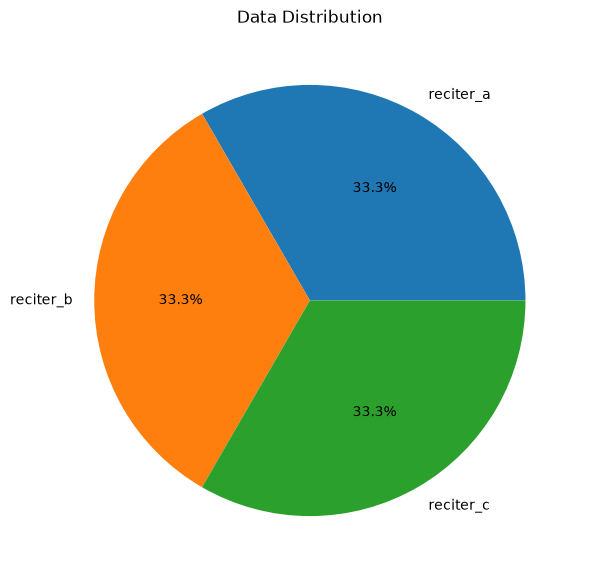

In [6]:
plt.figure(figsize=(10, 7))
plt.pie(df['Class'].value_counts(), labels=df['Class'].unique(), autopct='%1.1f%%')
plt.title('Data Distribution')
plt.show()

In [7]:
## splitting the data train 60% -- val 20% -- test 20%


train, temp = train_test_split(
    df,
    test_size=0.4,
    stratify=df['Class'],
    random_state=42
)
val, test = train_test_split(
    temp,
    test_size=0.5,
    stratify=temp['Class'],
    random_state=42
)

print(f"Train shape : {train.shape}")
print(f"Val shape : {val.shape}")
print(f"Test shape : {test.shape}")

Train shape : (43, 2)
Val shape : (14, 2)
Test shape : (15, 2)


In [8]:
label_encoder = LabelEncoder()
label_encoder.fit(df['Class'])

class Data(Dataset):
  def __init__(self, df):
    self.df = df
    self.labels = torch.tensor(label_encoder.transform(df['Class']), dtype=torch.long)
    self.audios = [torch.Tensor(self.get_specrogram(path)).unsqueeze(0).type(torch.FloatTensor) for path in df['FilePath']]

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, idx):
    audio = self.audios[idx].to(device)
    label = self.labels[idx].to(device)
    return audio, label

  def get_specrogram(self, path):
    img_height = 128
    img_width = 256

    with wave.open(path, 'rb') as audio_file:
      sr = audio_file.getframerate()
      frames = audio_file.readframes(audio_file.getnframes())

    signal = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
    if len(signal) < 512:
      signal = np.pad(signal, (0, 512 - len(signal)))

    frame_size = 512
    hop = 256
    windows = []
    for start_idx in range(0, len(signal) - frame_size + 1, hop):
      frame = signal[start_idx:start_idx + frame_size] * np.hanning(frame_size)
      spectrum = np.abs(np.fft.rfft(frame))[:img_height]
      windows.append(spectrum)

    spec = np.array(windows).T
    spec = np.log1p(spec)
    spec = spec / (spec.max() + 1e-8)

    x_old = np.linspace(0, 1, spec.shape[1])
    x_new = np.linspace(0, 1, img_width)
    resized = np.vstack([np.interp(x_new, x_old, row) for row in spec])
    return resized

In [9]:
train_data = Data(train)
val_data = Data(val)
test_data = Data(test)
print(f"Train shape : {len(train_data)}")
print(f"Val shape : {len(val_data)}")
print(f"Test shape : {len(test_data)}")

Train shape : 43
Val shape : 14
Test shape : 15


In [10]:
LR = 1e-3
BATCH_SIZE = 8
EPOCHS = 12

In [11]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

## Train an audio CNN

The CNN learns from spectrograms instead of raw waveforms.


In [12]:
class Zen(nn.Module):
  def __init__(self):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((4, 4))
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64 * 4 * 4, 128),
        nn.ReLU(),
        nn.Dropout(0.25),
        nn.Linear(128, len(df['Class'].unique()))
    )

  def forward(self, X):
    X = self.features(X)
    X = self.classifier(X)
    return X

model = Zen().to(device)

In [13]:
from torchsummary import summary
summary(model, (1, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
       BatchNorm2d-2         [-1, 16, 128, 256]              32
              ReLU-3         [-1, 16, 128, 256]               0
         MaxPool2d-4          [-1, 16, 64, 128]               0
            Conv2d-5          [-1, 32, 64, 128]           4,640
       BatchNorm2d-6          [-1, 32, 64, 128]              64
              ReLU-7          [-1, 32, 64, 128]               0
         MaxPool2d-8           [-1, 32, 32, 64]               0
            Conv2d-9           [-1, 64, 32, 64]          18,496
      BatchNorm2d-10           [-1, 64, 32, 64]             128
             ReLU-11           [-1, 64, 32, 64]               0
AdaptiveAvgPool2d-12             [-1, 64, 4, 4]               0
          Flatten-13                 [-1, 1024]               0
           Linear-14                  [

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(params=model.parameters(), lr=LR)

In [15]:
total_train_loss_plot = []
total_train_acc_plot = []
total_val_loss_plot = []
total_val_acc_plot = []

start = time.time()

for epoch in range(EPOCHS):
  total_acc_train, total_loss_train, total_loss_val, total_acc_val = 0, 0, 0, 0

  model.train()
  for inputs, labels in train_loader:
    outputs = model(inputs)

    train_loss = loss_fn(outputs, labels)
    total_loss_train += train_loss.item()

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc

  model.eval()
  with torch.inference_mode():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = loss_fn(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  total_train_loss_plot.append(round(total_loss_train/len(train_data), 4))
  total_train_acc_plot.append(round(total_acc_train/len(train_data)*100, 4))

  total_val_loss_plot.append(round(total_loss_val/len(val_data), 4))
  total_val_acc_plot.append(round(total_acc_val/len(val_data)*100, 4))

  print(f"Epoch : {epoch+1} | "
      f"Train Loss : {total_train_loss_plot[-1]} | "
      f"Train Accuracy : {total_train_acc_plot[-1]} | "
      f"Validation Loss : {total_val_loss_plot[-1]} | "
      f"Validation Acc : {total_val_acc_plot[-1]}")

end = time.time()
print(f"Training took {round(end - start, 2)} seconds")

Epoch : 1 | Train Loss : 0.1461 | Train Accuracy : 58.1395 | Validation Loss : 0.1569 | Validation Acc : 28.5714


Epoch : 2 | Train Loss : 0.0844 | Train Accuracy : 79.0698 | Validation Loss : 0.1517 | Validation Acc : 35.7143


Epoch : 3 | Train Loss : 0.0491 | Train Accuracy : 100.0 | Validation Loss : 0.1352 | Validation Acc : 35.7143


Epoch : 4 | Train Loss : 0.0321 | Train Accuracy : 95.3488 | Validation Loss : 0.0973 | Validation Acc : 71.4286


Epoch : 5 | Train Loss : 0.0101 | Train Accuracy : 100.0 | Validation Loss : 0.0712 | Validation Acc : 71.4286


...

Epoch : 8 | Train Loss : 0.0013 | Train Accuracy : 100.0 | Validation Loss : 0.0098 | Validation Acc : 100.0


Epoch : 9 | Train Loss : 0.0007 | Train Accuracy : 100.0 | Validation Loss : 0.0011 | Validation Acc : 100.0


Epoch : 10 | Train Loss : 0.0009 | Train Accuracy : 100.0 | Validation Loss : 0.0003 | Validation Acc : 100.0


Epoch : 11 | Train Loss : 0.0004 | Train Accuracy : 100.0 | Validation Loss : 0.0004 | Validation Acc : 100.0


Epoch : 12 | Train Loss : 0.0004 | Train Accuracy : 100.0 | Validation Loss : 0.0001 | Validation Acc : 100.0
Training took 3.59 seconds


## Evaluate the model

The test split gives a basic check of model performance.


In [16]:
model.eval()
with torch.inference_mode():
  total_acc_test, total_loss_test = 0, 0
  for inputs, labels in test_loader:
    outputs = model(inputs)
    test_loss = loss_fn(outputs, labels)
    total_loss_test += test_loss.item()

    test_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_test += test_acc

  print(f"Test Loss : {round(total_loss_test/len(test_data), 4)} | "
      f"Test Acc : {round(total_acc_test/len(test_data)*100, 4)}")

Test Loss : 0.0002 | Test Acc : 100.0


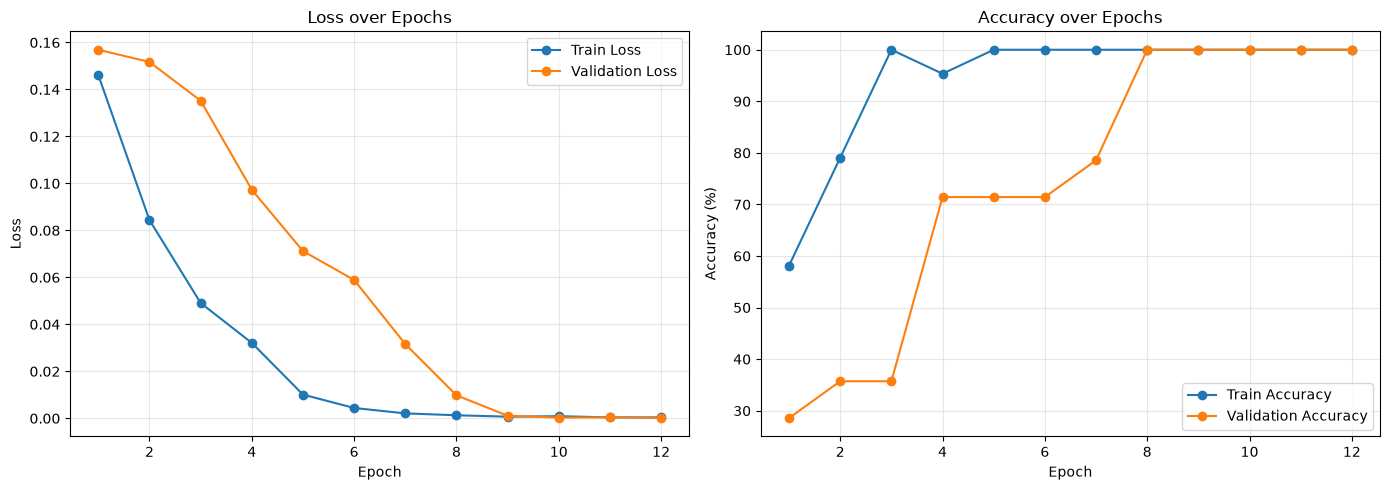

Final Train Loss: 0.0004 | Final Train Accuracy: 100.0%
Final Validation Loss: 0.0001 | Final Validation Accuracy: 100.0%
Best Validation Accuracy: 100.0% (Epoch 8)


In [17]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(total_train_loss_plot) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, total_train_loss_plot, label='Train Loss', marker='o')
axes[0].plot(epochs_range, total_val_loss_plot, label='Validation Loss', marker='o')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, total_train_acc_plot, label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, total_val_acc_plot, label='Validation Accuracy', marker='o')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Train Loss: {total_train_loss_plot[-1]} | Final Train Accuracy: {total_train_acc_plot[-1]}%")
print(f"Final Validation Loss: {total_val_loss_plot[-1]} | Final Validation Accuracy: {total_val_acc_plot[-1]}%")
print(f"Best Validation Accuracy: {max(total_val_acc_plot)}% (Epoch {total_val_acc_plot.index(max(total_val_acc_plot)) + 1})")